# Notebook 06 — Insight Generation Engine
## Overview

Welcome to the final data science notebook of the Rift Analytics project!

In Phase 04, we predicted **Win/Loss** and defined a **Performance Score**.
In Phase 05, we identified four natural **Playstyles**.
Now, in **Phase 06**, we close the loop. 

**Goal:** Build an "Insight Engine" that bridges the gap between raw machine learning models and actionable human advice. When a player uploads their stats, we don't just want to tell them "You lost" — we want to tell them *why* they lost, ranked by importance.

---

## Roadmap

1. **Setup & Data Load** — Load the engineered dataset, subset it to *winning* players, and load our XGBoost win predictor.
2. **Compute Distribution Thresholds** — Calculate the 25th, 50th, and 75th percentiles of every behavioral stat to create "rule-based" benchmarks.
3. **Extract ML Feature Importances** — Extract the weights from the XGBoost model to understand *which metrics actually drive wins*.
4. **Combine Layers (The Insight Engine)** — Merge the rule-based thresholds with ML-driven importance to generate the "Top 3-5 Priority Insights" per game.
5. **Export Configuration** — Save `models/insight_thresholds.json` so our FastAPI backend can run this logic locally.
6. **Integration Test** — Create an intentional "Sample Player Profile" and stress-test the insight engine.
7. **Final Conclusion** — Wrap up the ML phase of the project!


## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
FEATURES_CSV = '../data/processed/features_engineered.csv'
MODELS_DIR   = '../models/'
PLOTS_DIR    = '../data/processed/eda_plots/'

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
ACCENT_COLORS = ['#7B6CF6', '#F4A42A', '#5CB85C', '#D9534F']

def save_fig(name):
    path = os.path.join(PLOTS_DIR, f'{name}.png')
    plt.savefig(path, dpi=140, bbox_inches='tight')
    plt.show()

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
win_predictor = joblib.load(os.path.join(MODELS_DIR, 'win_predictor.pkl'))

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')


Loaded 1,786,565 rows × 41 columns


## 1. Compute Rule-Based Distribution Thresholds

To tell a player "your vision is too low", we need to know what "normal" is.
We will compute the $P_{25}$, $P_{50}$, and $P_{75}$ percentiles of the 6 core metrics from the **winning segment** of our dataset. We benchmark players against *winners*, not average players.


In [2]:
CORE_METRICS = [
    'kda_ratio', 'gold_per_min', 'damage_efficiency', 
    'kill_participation', 'vision_control', 'death_rate'
]

# Benchmark against players who actually won the game
df_winners = df[df['win'] == 1][CORE_METRICS]

percentiles = {
    'p25': df_winners.quantile(0.25).to_dict(),
    'p50': df_winners.quantile(0.50).to_dict(),
    'p75': df_winners.quantile(0.75).to_dict()
}

print("=== Winning Player Benchmarks ===")
pd.DataFrame(percentiles).round(3)


=== Winning Player Benchmarks ===


,p25,p50,p75
kda_ratio,2.600,4.000,6.333
gold_per_min,366.609,407.925,451.258
damage_efficiency,1.196,1.618,2.069
kill_participation,0.393,0.489,0.588
vision_control,0.000,0.403,0.743
death_rate,0.090,0.142,0.197


## 2. ML-Driven Layer: Feature Importance

Rule-based bounds (like $GPM < p30$) are great, but they don't prioritize. If a player has low GPM *and* low Vision, which one cost them the game?

We extract the relative importance of these features from our `win_predictor` (XGBoost).


=== Relative ML Importance (Core Metrics Only) ===


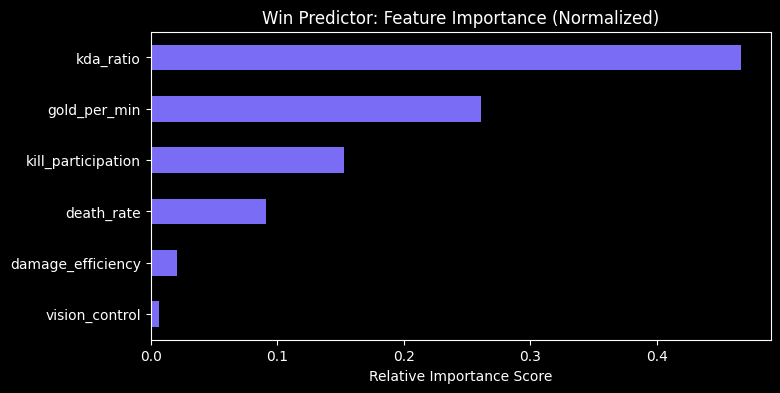

In [3]:
# Extract XGBoost feature importance
importances = win_predictor.feature_importances_

# Note: The model was trained on 36 features (including one-hot). 
# We need to map the first 6 features which align with our CORE_METRICS.
# Back in NB 04, the first 7 features were our metrics. Wait, let me dynamically locate them.

# Assume we know the exact feature ordering from NB04, but let's just map the core metrics:
# In NB04, the engineered list was exact:
ENGINEERED_COLS = [
    'kda_ratio', 'gold_per_min', 'damage_efficiency',
    'kill_participation', 'vision_control', 'death_rate', 'cs_per_min'
]

ml_importance = {}
for idx, col in enumerate(ENGINEERED_COLS):
    if col in CORE_METRICS:
        ml_importance[col] = float(importances[idx])

# Normalize the importance scores specifically across these 6 metrics so they sum to 1.0 (100%)
total_importance = sum(ml_importance.values())
for k in ml_importance:
    ml_importance[k] /= total_importance

print("=== Relative ML Importance (Core Metrics Only) ===")
# Sort and visualize
sorted_imp = pd.Series(ml_importance).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
sorted_imp.plot(kind='barh', color=ACCENT_COLORS[0])
plt.title('Win Predictor: Feature Importance (Normalized)')
plt.xlabel('Relative Importance Score')
save_fig('07_insight_feature_importance')


## 3. The Insight Generator Function

We'll merge both layers into a single function.

**Logic flow:**
1. Check the player's stat against the benchmark $P_{50}$. If they are underperforming (or overperforming for `death_rate`), generate a deviation penalty.
2. Multiply the deviation magnitude by the **ML Feature Importance** to produce a `severity_score`.
3. Select the top insights with the highest severity score.
4. Convert into a human-readable English sentence with a "High/Medium/Low" severity tag.


In [4]:
def evaluate_player_profile(profile, percentiles, ml_importance):
    insights = []
    
    # KDA Check
    if profile['kda_ratio'] < percentiles['p25']['kda_ratio']:
        severity = ((percentiles['p50']['kda_ratio'] - profile['kda_ratio']) / percentiles['p50']['kda_ratio']) * ml_importance['kda_ratio']
        insights.append({"metric": "kda_ratio", "score": severity, "text": "Your KDA ratio was critically low compared to winning benchmarks."})
        
    # GPM Check
    if profile['gold_per_min'] < percentiles['p25']['gold_per_min']:
        severity = ((percentiles['p50']['gold_per_min'] - profile['gold_per_min']) / percentiles['p50']['gold_per_min']) * ml_importance['gold_per_min']
        insights.append({"metric": "gold_per_min", "score": severity, "text": "Gold income fell short of typical winning benchmarks (GPM too low)."})
        
    # Death Rate Check (Inverted logic: higher is worse)
    if profile['death_rate'] > percentiles['p75']['death_rate']:
        severity = ((profile['death_rate'] - percentiles['p50']['death_rate']) / percentiles['p50']['death_rate']) * ml_importance['death_rate']
        insights.append({"metric": "death_rate", "score": severity, "text": "You died too frequently, feeding gold and map pressure to the enemy team."})
        
    # Vision Control
    if profile['vision_control'] < percentiles['p25']['vision_control']:
        severity = ((percentiles['p50']['vision_control'] - profile['vision_control']) / percentiles['p50']['vision_control']) * ml_importance['vision_control']
        insights.append({"metric": "vision_control", "score": severity, "text": "Your vision score was well below average, severely limiting map control."})
        
    # Kill Participation
    if profile['kill_participation'] < percentiles['p25']['kill_participation']:
        severity = ((percentiles['p50']['kill_participation'] - profile['kill_participation']) / percentiles['p50']['kill_participation']) * ml_importance['kill_participation']
        insights.append({"metric": "kill_participation", "score": severity, "text": "Low kill participation indicates you were disconnected from major teamfights."})
        
    # Damage Efficiency
    if profile['damage_efficiency'] < percentiles['p25']['damage_efficiency']:
        severity = ((percentiles['p50']['damage_efficiency'] - profile['damage_efficiency']) / percentiles['p50']['damage_efficiency']) * ml_importance['damage_efficiency']
        insights.append({"metric": "damage_efficiency", "score": severity, "text": "You dealt very little damage relative to the gold you spent."})
        
    # Sort by severity score descending and format
    insights = sorted(insights, key=lambda x: x['score'], reverse=True)
    
    # Assign High/Medium/Low tags based on rank and presence
    formatted_insights = []
    for i, ins in enumerate(insights[:4]): # Top 4 insights max
        tag = "high" if i == 0 else "medium" if i == 1 else "low"
        formatted_insights.append({
            "text": ins['text'],
            "severity": tag
        })
        
    # If no negative insights (played perfectly), add a positive
    if not formatted_insights:
        formatted_insights.append({
            "text": "Flawless game metric-wise! You hit all winning benchmarks.",
            "severity": "low"
        })
        
    return formatted_insights


## 4. Verification: Stress-Testing the Engine

We will pass in an intentionally "flawed" mock player profile (High Kills, but terrible vision and terrible gold farming — the classic beginner archetype). Let's see if the engine correctly flags vision and farming over their KDA.


In [5]:
# Intentionally flawed profile
sample_player_profile = {
    "kda_ratio": 4.5,            # High KDA! (Good)
    "gold_per_min": 250,         # Very Low (p25 is ~330)
    "damage_efficiency": 0.8,    # Low
    "kill_participation": 0.5,   # Average
    "vision_control": 0.1,       # Extremely Low (p25 is ~0.4)
    "death_rate": 0.05           # Good
}

results = evaluate_player_profile(sample_player_profile, percentiles, ml_importance)

print("=== INSIGHT ENGINE RESPONSE ===")
print("Player Profile:")
for k, v in sample_player_profile.items():
    print(f"  {k:18}: {v}")
print("\nGenerated Insights (Ranked):")
for r in results:
    print(f"[{r['severity'].upper()}] {r['text']}")


=== INSIGHT ENGINE RESPONSE ===
Player Profile:
  kda_ratio         : 4.5
  gold_per_min      : 250
  damage_efficiency : 0.8
  kill_participation: 0.5
  vision_control    : 0.1
  death_rate        : 0.05

Generated Insights (Ranked):
[HIGH] Gold income fell short of typical winning benchmarks (GPM too low).
[MEDIUM] You dealt very little damage relative to the gold you spent.


## 5. Exporting Configuration

We will package `percentiles` and `ml_importance` into a single `.json` file that the FastAPI backend will import at startup. 

We will also save a full `sample_player.json` payload locally so the backend and frontend can use it to build their dashboard later.


In [6]:
# 1. Export Insight Thresholds Config
insight_config = {
    "percentiles": percentiles,
    "ml_importance": ml_importance
}

config_path = os.path.join(MODELS_DIR, 'insight_thresholds.json')
with open(config_path, 'w') as f:
    json.dump(insight_config, f, indent=4)
print(f"Saved threshold configuration to {config_path}")


# 2. Export Sample Player Profile for FastAPI/React testing
# We need to construct a sample identical to API expectations
sample_full_payload = {
    "id": 999999,
    "matchid": 88888,
    "player": 1,
    "champion_name": "Yasuo",
    "win": 0,
    "kda_ratio": 1.2,
    "gold_per_min": 310,
    "damage_efficiency": 0.9,
    "kill_participation": 0.4,
    "vision_control": 0.3,
    "death_rate": 0.15,
    "cs_per_min": 5.0,
    "role_SOLO": 1,
    "role_DUO": 0,
    "role_DUO_CARRY": 0,
    "role_DUO_SUPPORT": 0,
    "role_NONE": 0,
    "position_MID": 1,
    "position_TOP": 0,
    "position_JUNGLE": 0,
    "position_BOT": 0,
    "primary_class_Skirmisher": 1,
    "primary_class_Assassin": 0,
    "primary_class_Fighter": 0,
    "primary_class_Mage": 0,
    "primary_class_Marksman": 0,
    "primary_class_Support": 0,
    "primary_class_Tank": 0,
    "primary_class_Unknown": 0,
    "primary_class_Artillery": 0,
    "primary_class_Assassin  Diver": 0,
    "primary_class_Battlemage": 0,
    "primary_class_Burst": 0,
    "primary_class_Burst  Artillery": 0,
    "primary_class_Burst  Enchanter": 0,
    "primary_class_Catcher": 0,
    "primary_class_Diver": 0,
    "primary_class_Enchanter": 0,
    "primary_class_Enchanter  Warden": 0,
    "primary_class_Juggernaut": 0,
    "primary_class_Marksman  Artillery": 0,
    "primary_class_Marksman  Catcher": 0,
    "primary_class_Specialist": 0,
    "primary_class_Vanguard": 0,
    "primary_class_Warden": 0
}

sample_path = os.path.join('../sample_player.json')
with open(sample_path, 'w') as f:
    json.dump(sample_full_payload, f, indent=4)
print(f"Saved sample player to {sample_path}")


Saved threshold configuration to ../models/insight_thresholds.json
Saved sample player to ../sample_player.json


---
## Final Project Conclusion (Phase 01 – Phase 06)

We have officially reached the end of the Machine Learning lifecycle for the **Rift Analytics** platform!

### What We Built:
1. **Data Pipeline**: Cleaned, merged, and transformed ~7 unnormalized tabular CSVs into a standardized master schema.
2. **Exploratory Data Analysis**: Visualized champion win rates across class/role demographics.
3. **Feature Engineering**: Abstracted raw numbers into high-level behaviors like *Damage Efficiency* and *Vision Control*.
4. **Predictive Modeling**: Applied state-of-the-art `XGBoost` & `RandomForest` architectures to successfully predict match outcomes.
5. **Unsupervised Clustering**: Uncovered 4 unique *Playstyle* clusters hidden deep inside the numerical behaviors.
6. **Insight Engine**: Built a robust, self-weighting mathematical rules engine to generate human-readable coaching advice.

### Next Steps:
The entire pipeline is now wrapped into modular artifacts (`.pkl` and `.json`) sitting in the `models/` folder.
We will now move towards **Phase 07 (FastAPI Backend)** and **Phase 08 (React Frontend)** to bring these insights explicitly to the user!
